In [1]:
import numpy as np

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/raw_data/sudan (1).csv")

In [3]:
df["country"]="Sudan"
df["date"]=pd.to_datetime(df["YEAR"]*1000+df["DOY"], format="%Y%j")
df["Month"]=df["date"].dt.month

In [4]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


Most variables appear to have relatively similar mean and median values, suggesting that their distributions are not strongly skewed. However, **RH2M** shows a noticeable difference between its mean and median, indicating that its distribution is skewed. Its standard deviation of **17** also shows that relative humidity has considerable variability around its mean.


In [6]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
Month          0
dtype: int64

In [7]:
missing_percentage=df.isna().mean()*100

In [8]:
missing_percentage[missing_percentage>5]

Series([], dtype: float64)

In [9]:
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

In [10]:
Z_score=(df[cols]-df[cols].mean())/df[cols].std()

In [11]:
outlier_rows=(Z_score.abs()>3).any(axis=1)

In [12]:
outlier_rows.sum()

np.int64(84)

In [13]:
row_missing_percentage = df.isna().mean(axis=1) * 100

In [14]:
df=df[row_missing_percentage<=30]

In [15]:
df.to_csv("../data/processed_data/sudan_clean.csv", index=False)

In [16]:
monthly_T2M=df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

In [17]:
monthly_T2M["date"]=pd.to_datetime(
    monthly_T2M["YEAR"].astype(str)+"-"+monthly_T2M["Month"].astype(str)+"-01"
)

In [18]:
peak_tempMAX=monthly_T2M.loc[monthly_T2M["T2M"].idxmax()]

In [19]:
peak_tempMIN=monthly_T2M.loc[monthly_T2M["T2M"].idxmin()]

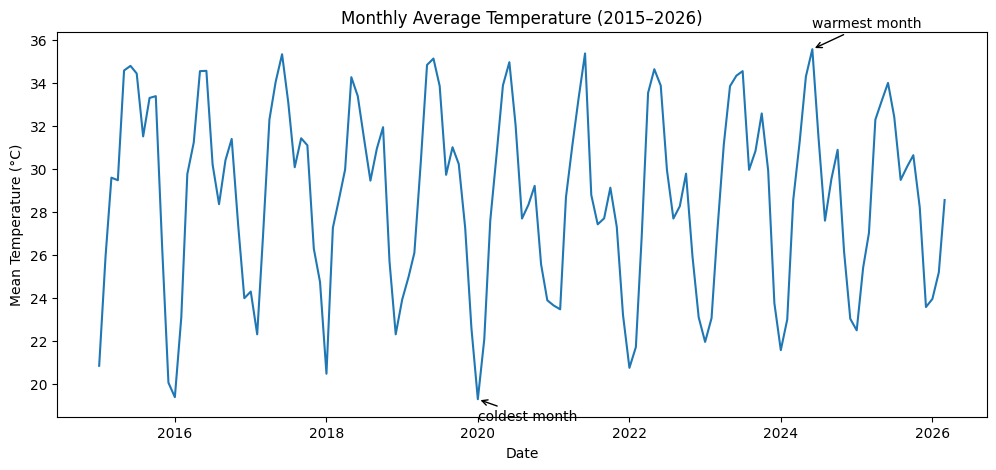

In [20]:
plt.figure(figsize=(12,5))
plt.plot(monthly_T2M["date"], monthly_T2M["T2M"])
plt.annotate(
    "warmest month",
    xy=(peak_tempMAX["date"], peak_tempMAX["T2M"]),
    xytext=(peak_tempMAX["date"], peak_tempMAX["T2M"]+1),
    arrowprops=dict(arrowstyle="->")
)
plt.annotate(
    "coldest month",
    xy=(peak_tempMIN["date"], peak_tempMIN["T2M"]),
    xytext=(peak_tempMIN["date"], peak_tempMIN["T2M"]-1),
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Monthly Average Temperature (2015–2026)")

plt.show()

the tempreture is evenly distributed


In [21]:
monthly_prec=df.groupby(["Month"])["PRECTOTCORR"].sum().reset_index()

In [22]:
peak_prec=monthly_prec.loc[monthly_prec["PRECTOTCORR"].idxmax()]

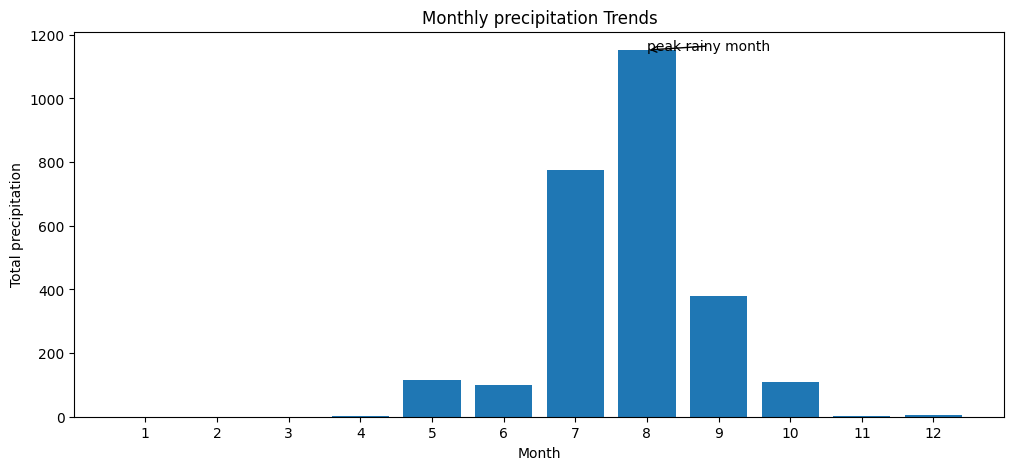

In [23]:
plt.figure(figsize=(12,5))
plt.bar(monthly_prec["Month"],monthly_prec["PRECTOTCORR"])
plt.annotate(
    "peak rainy month",
    xy=(peak_prec["Month"], peak_prec["PRECTOTCORR"]),
    xytext=(peak_prec["Month"], peak_prec["PRECTOTCORR"]),
    arrowprops=dict(arrowstyle="->")
    
)
plt.xlabel("Month")
plt.ylabel("Total precipitation")
plt.title("Monthly precipitation Trends")
plt.xticks(range(1, 13))
plt.show()

The country is mainly dry throughout the year, with a more noticeable wet period from **May to October**. **July and August** receive the most prominent rainfall, while the other months within this period experience some rainfall but generally have shorter or less intense wet periods.


In [24]:
number=df.select_dtypes(include="number")

In [25]:
correlation=number.corr()

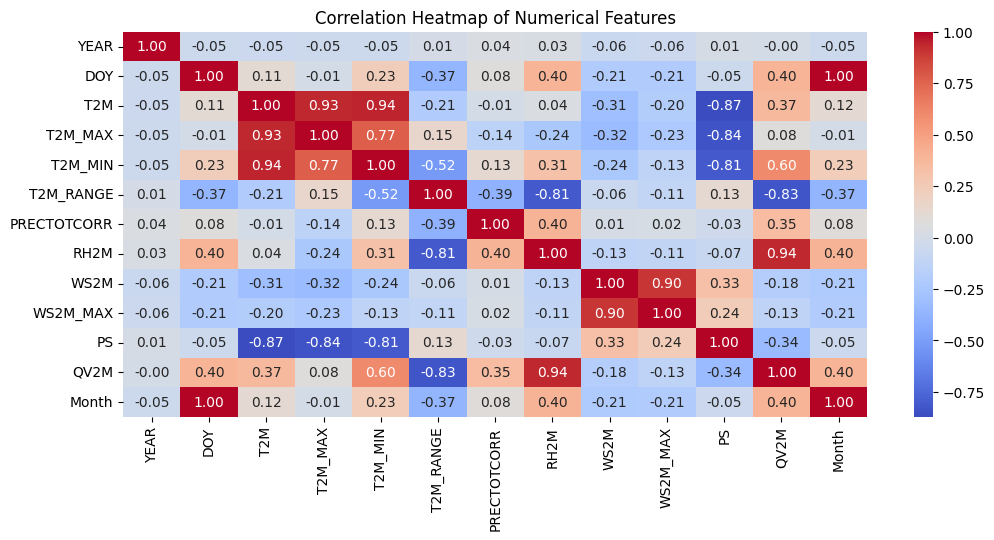

In [26]:
plt.figure(figsize=(12,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

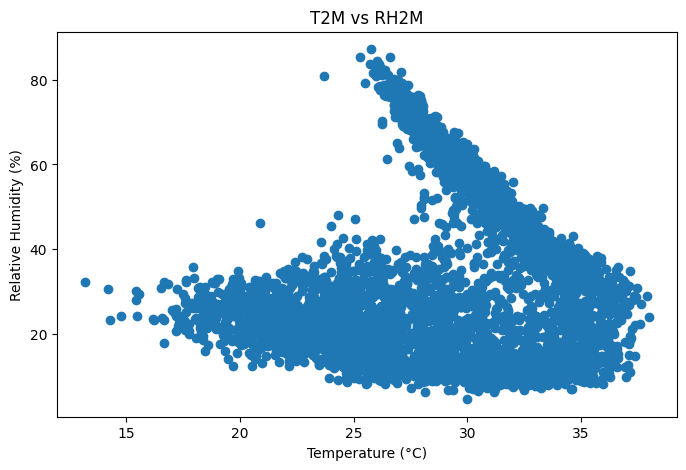

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")

plt.show()

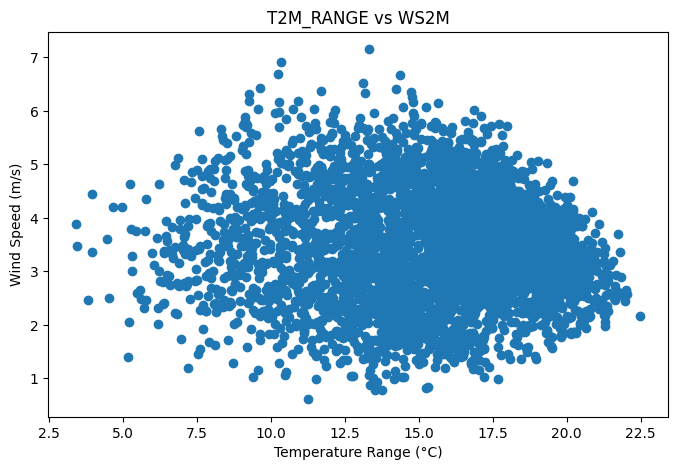

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.title("T2M_RANGE vs WS2M")
plt.show()

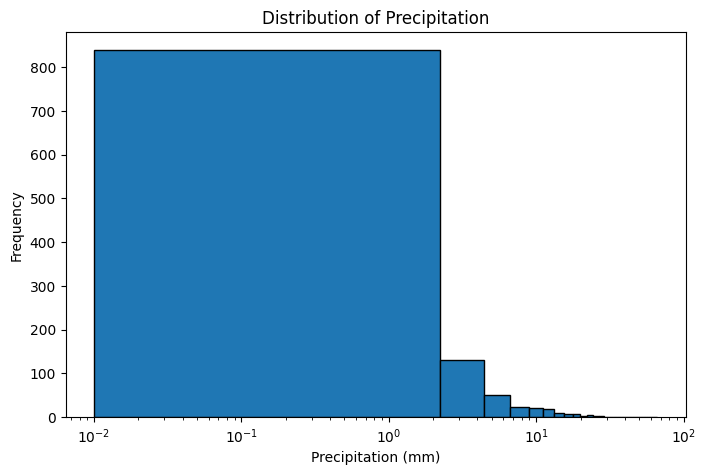

In [29]:
rain=df.loc[df["PRECTOTCORR"]>0, "PRECTOTCORR"]
plt.figure(figsize=(8,5))
plt.hist(rain, bins=30, edgecolor="black")
plt.xscale("log")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation")
plt.show()

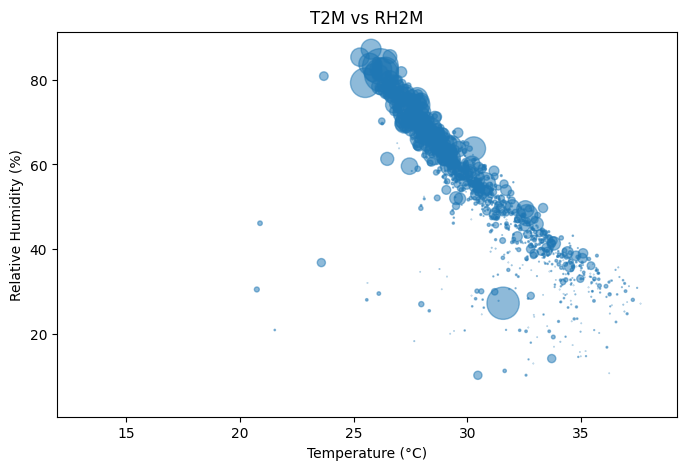

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"],df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5 )
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")
plt.show()